#**ML Mini-Task: Построение регрессионной модели для предсказания биологической активности**
Этот мини-таск является частью хакатона DataCon 2025 и продолжает работу с данными, подготовленными участниками на 3-й день. Целью является построение предсказательной модели, способной оценивать активность молекул в отношении конкретной биомишени. Ваш датасет посвящен набору веществ, активных в отношении Estrogen receptor alpha (ERα), белок, известный также как ESR1. Это нуклеарный гормональный рецептор, активируемый эстрогенами. Он является транскрипционным фактором, контролирующим экспрессию генов, связанных с развитием, репродукцией, метаболизмом, поддержанием костной ткани и даже раком молочной железы.

🎯 Цель
Построить и оценить регрессионную модель, предсказывающую значение биологической активности (pValue) молекул на основе их структурных признаков.

P.S.: Параметр pValue это десятичный логаримф одной из метрик активности

* pKi = –log₁₀(Ki)
* pIC₅₀ = –log₁₀(IC₅₀)
* pEC₅₀ = –log₁₀(EC₅₀)

Где:

Ki — ингибиторная константа (чем меньше, тем сильнее вещество связывается с мишенью),
IC₅₀ — концентрация, при которой ингибируется 50% активности,
EC₅₀ — концентрация, вызывающая 50% максимального эффекта.
Все значения Ki, IC₅₀, EC₅₀, как правило, представлены в наномолях (нM).

📈 Как интерпретировать pValue?

Чем выше pValue — тем активнее молекула в отношении мишени (в нашем случае — Estrogen Receptor Alpha, CHEMBL206).

📂 Входные данные
Участники используют уже подготовленный датасет из предыдущего мини-таска. Он должен содержать:

Признаки молекул (только фингерпринты) или (фингерпринты + дескрипторы).

Целевую переменную — pValue (логарифмированное значение активности).

P.S. Помните про проклятие размерности

🧠 Этапы задания
#**1. 📥 Загрузка и первичный анализ**
Загрузите подготовленный датасет.
Посмотрите на распределение pValue, проверьте на выбросы и артефакты.
#**2. 🧪 Разделение выборки**
Проведите разбиение на train/test с учётом распределения pValue. (Можете использовать любые обоснованные и уместные способы разбиения данных на выборки)
#**3. ⚙️ Построение базовых моделей**
Выберите несколько базовых моделей регрессии:
LinearRegression
RandomForestRegressor
XGBRegressor, LGBMRegressor, CatBoostRegressor
KNeighborsRegressor
Ridge, Lasso
Обучите и сравните их с помощью кросс-валидации (R², MAE, MAPE).
#**4. 🔍 Выбор лучшей модели и тюнинг**
Выберите наилучшую модель по результатам кросс-валидации.
Проведите подбор гиперпараметров с помощью Optuna или GridSearchCV.
#**5. 📊 Финальная оценка**
Проведите финальное обучение на всей train-выборке.
Оцените модель:
через кросс-валидацию
и отдельно (единожды и только в самом конце) на hold-out test-сете (для подтверждения обобщающей способности).
#**6. 📈 Дополнительно (по желанию)**
Постройте кривую обучения (learning curve).
Выведите ТОП-важные признаки по итогам модели.
Обучите модель на ТОП-важных признаков.
Оцените метрики модели, обученной на урезанном количестве признаков.
📝 Что сдать
Jupyter Notebook (.ipynb) с кодом и пояснениями.
Краткое описание того, какую модель выбрали и почему.
Финальные метрики (MAE, MAPE, R²) на кросс-валидации и тесте.


Сначалы мы импортируем все необходимые библиотеки для обучения регрессионной модели

In [1]:
!pip install catboost
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.7 MB/s eta 0:00:00


In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, make_scorer
import optuna
from optuna.samplers import TPESampler

Теперь загружаем наш датасет из гугл диска. Он содержит фингерпринты, pValue=-lg(Ki)

In [3]:
df = pd.read_csv('/content/final_dataset.csv')
df

,molecule_chembl_id,smiles,pValue,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,...,pca_155,pca_156,pca_157,pca_158,pca_159,pca_160,pca_161,pca_162,pca_163,pca_164
0,CHEMBL59146,O=C(c1ccc(OCCN2CCCCC2)cc1)N1c2ccc(O)cc2CCC1c1c...,7.537602,-3.150489,0.698173,-5.481721,5.610144,3.417993,0.459906,1.830435,...,0.123832,0.648487,0.367322,0.610349,0.275015,-0.668213,0.264313,-0.342675,-0.224253,0.091290
1,CHEMBL60538,Oc1ccc2c(c1)CCC(c1ccccc1)N2Cc1ccc(OCCN2CCCCC2)cc1,8.769551,-2.935748,0.647289,-4.007752,4.652561,4.960398,0.174448,2.767493,...,0.147603,0.075758,0.011288,0.136389,-0.794251,0.159795,-0.348831,0.175974,0.641845,0.612565
2,CHEMBL81,O=C(c1ccc(OCCN2CCCCC2)cc1)c1c(-c2ccc(O)cc2)sc2...,9.397940,-1.337966,-0.582314,-6.086179,6.924186,1.978768,2.918317,-0.766935,...,0.784366,-0.531682,-0.093146,-0.408064,-0.033040,-0.897237,0.036396,-0.360340,1.124336,-0.612835
3,CHEMBL293599,Oc1ccc(C2CCc3cc(O)ccc3N2)cc1,6.769551,-3.276266,-0.265532,-0.783125,-0.250849,0.736851,0.058282,0.552373,...,0.719985,0.225088,0.817000,-0.556158,1.387769,0.456744,1.431345,0.770460,-1.088433,0.115543
4,CHEMBL56306,Oc1ccc(C2CCc3cc(O)ccc3N2Cc2ccc(OCCN3CCCC3)cc2)cc1,8.958607,-2.698546,1.020813,-4.246992,4.621513,5.178048,0.217756,2.509228,...,0.309492,-0.500039,-0.379633,0.024847,-0.210576,-0.006847,-0.018775,0.003116,0.083247,0.129955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,CHEMBL5769467,Cc1cccc2c1OC(c1ccc(OCCN3CC(CF)C3)cc1)c1c-2cnc2...,8.494850,-2.852547,1.501388,-9.565998,15.054246,1.465094,-8.100887,-1.574679,...,-0.858323,-0.303872,0.852488,0.834525,-0.691692,0.203601,0.470782,0.593103,-0.170383,1.174626
696,CHEMBL5797158,Cc1cccc2c1O[C@@H](c1ccc(OCCN3CC(CF)C3)cc1)c1c-...,8.030118,-2.852547,1.501388,-9.565998,15.054246,1.465094,-8.100887,-1.574679,...,-0.858323,-0.303872,0.852488,0.834525,-0.691692,0.203601,0.470782,0.593103,-0.170383,1.174626
697,CHEMBL5751804,Cc1cccc2c1O[C@H](c1ccc(OCCN3CC(CF)C3)cc1)c1c-2...,9.026872,-2.852547,1.501388,-9.565998,15.054246,1.465094,-8.100887,-1.574679,...,-0.858323,-0.303872,0.852488,0.834525,-0.691692,0.203601,0.470782,0.593103,-0.170383,1.174626
698,CHEMBL5816503,Oc1ccc2c3c(cnc2c1)-c1ccc(Cl)cc1O[C@@H]3c1ccc(O...,9.229148,-3.053635,0.945108,-9.611208,14.986369,3.978721,-7.926972,-1.027647,...,0.269463,-0.097197,-0.262804,-0.474570,-0.540657,0.281936,0.816866,-0.209895,-0.300624,0.750075


Теперь найдём распределение целевой переменной pValue и наличие выбросов

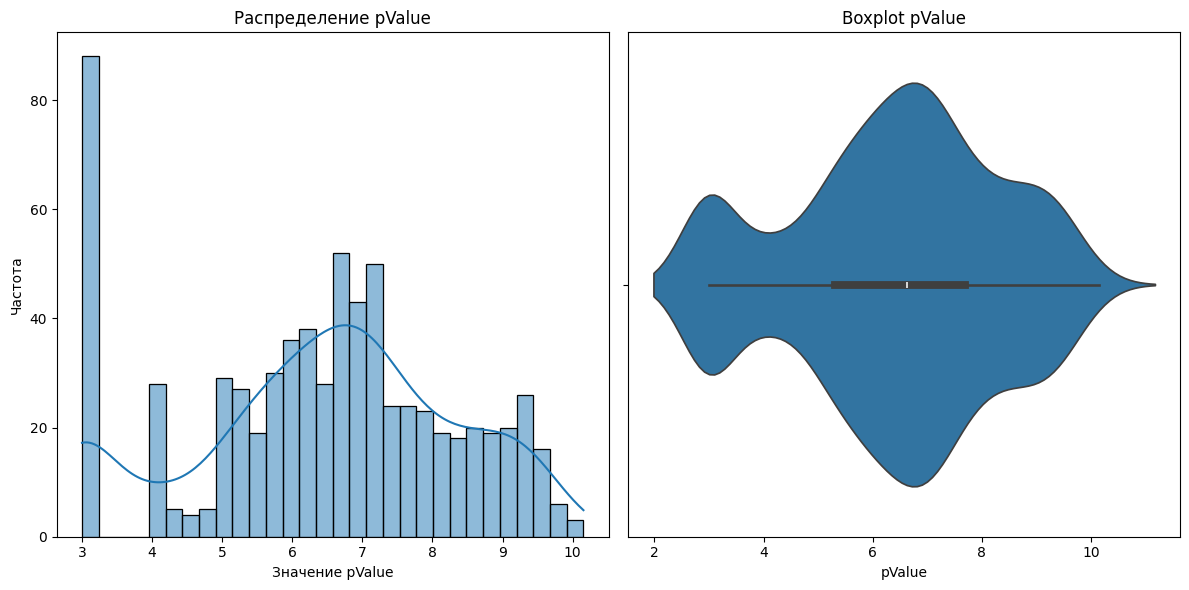

In [4]:
# Анализ распределения целевой переменной pValue
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['pValue'], bins=30, kde=True)
plt.title('Распределение pValue')
plt.xlabel('Значение pValue')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.violinplot(df,x=df['pValue'])
plt.title('Boxplot pValue')
plt.tight_layout()
plt.show()

мы видим, что распределение pValue непохоже на нормальное, так как местами есть провалы и есть очень маленькие значения pValue. У них наблюдается самая высокая частота.


Что касается violinplot, то можно заметить, что выбросов не наблюдается. Поэтому все данные оставляем в датасете.

Теперь на всякий случай проверим датасет на наличие дубликатов, чтобы не ухудшать качество обучения нашей модели.  Метод снижения размерности уже сделан над этим датасетом в минитаске 2  

In [5]:
print(f"Всего в датасете {df.duplicated().sum()} дубликатов")

Всего в датасете 0 дубликатов


Так как дубликатов не наблюдается и нет выбросов, то можно начинать обучение регрессинных моделей.

Сначала разобьём нашу выборку на тренировочную и тестовую (80:20) - это будет оптимальным балансом между обучением и валидацией. Так как распределение pValue не является нормальным, то мы будем использовать стратификацию по квантилям pValue, так как в тестовой выборке может не оказаться высокоактивных соединений и модель может не научится предсказывать активные соединения. В итоге разбиваем диапазон pValue на 4 квантиля (5 границ) и распределяем соединения из каждого квантиля пропорционально в train/test

In [6]:
# Выделение признаков и целевой переменной
X = df.drop(['molecule_chembl_id', 'smiles', 'pValue'], axis=1)
y = df['pValue']

# Стратифицированное разделение по квантилям pValue
bins = np.quantile(y, np.linspace(0, 1, 5))
y_binned = np.digitize(y, bins)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_binned, random_state=42
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (560, 164)
Размер тестовой выборки: (140, 164)


Теперь мы готовы обучать наши регрессионные модели

In [7]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=0.5),
    'Lasso': Lasso(alpha=0.),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(verbose=0, random_state=42)
}
 #Кросс-валидация (5 фолдов)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2').mean()
    cv_mae = cross_val_score(model, X_train, y_train, cv=kf,
                           scoring='neg_mean_absolute_error').mean() * -1 #мы ищем минимум ошибки
    cv_mape = cross_val_score(model, X_train, y_train, cv=kf,
                            scoring='neg_mean_absolute_percentage_error').mean() * -1 # Здесь точно также
    # добавление метрик качества моделей в список
    results.append({
        'Model': name,
        'R2': cv_r2,
        'MAE': cv_mae,
        'MAPE': cv_mape
    })

results_df = pd.DataFrame(results)
print("Результаты кросс-валидации:")
print(results_df.sort_values('R2', ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.931e+01, tolerance: 1.667e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24545
[LightGBM] [Info] Number of data points in the train set: 448, number of used features: 164
[LightGBM] [Info] Start training from score 6.365322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

Самой лучшей моделью оказался CatBoost - у него самый высокий R2. Хоть у него MAE и MAPE чуть похуже, чем у KNN, но он меньше склонен к переобучению, чем KNN, и лучше работает с большим количеством данных.

Теперь мы оптимизируем гиперпараметры нашей модели с помощью optuna

In [19]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42
    }

    model = LGBMRegressor(**params) #Распаковка словаря с параметрами
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean() # и снова кросс-валидация
    return score

In [20]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2025-12-15 16:08:15,046] A new study created in memory with name: no-name-fc5b3f72-d81d-429b-865d-aa697a580428


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24536
[LightGBM] [Info] Number of data points in the train set: 448, number of used features: 164
[LightGBM] [Info] Start training from score 6.468569
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[I 2025-12-15 16:08:17,271] Trial 0 finished with value: 0.7779733475802784 and parameters: {'max_depth': 3, 'learning_rate': 0.22184009611562133, 'num_leaves': 71, 'min_child_samples': 27, 'reg_alpha': 0.09215658787940517, 'reg_lambda': 0.017556916416042817}. Best is trial 0 with value: 0.7779733475802784.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-12-15 16:08:18,860] Trial 1 finished with value: 0.7169568660938268 and parameters: {'max_depth': 5, 'learning_rate': 0.024155848030975396, 'num_leaves': 27, 'min_child_samples': 45, 'reg_alpha': 1.4482437845054539, 'reg_lambda': 1.1181946904932547}. Best is trial 0 with value: 0.7779733475802784.


...

[I 2025-12-15 16:10:21,324] Trial 47 finished with value: 0.772388087389808 and parameters: {'max_depth': 4, 'learning_rate': 0.06133166583983837, 'num_leaves': 59, 'min_child_samples': 50, 'reg_alpha': 0.14199646419219136, 'reg_lambda': 0.001020877220796202}. Best is trial 25 with value: 0.7961578950890286.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-12-15 16:10:23,149] Trial 48 finished with value: 0.7818731152846509 and parameters: {'max_depth': 3, 'learning_rate': 0.08224104447067583, 'num_leaves': 42, 'min_child_samples': 37, 'reg_alpha': 0.005791635353613448, 'reg_lambda': 0.0044907668953722436}. Best is trial 25 with value: 0.7961578950890286.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-12-15 16:10:25,534] Trial 49 finished with value: 0.7748692930398136 and parameters: {'max_depth': 5, 'learning_rate': 0.09666656446972202, 'num_leaves': 32, 'min_child_samples': 29, 'reg_alpha': 0.016867416658726188, 'reg_lambda': 0.05572534803282684}. Best is trial 25 with value: 0.7961578950890286.


Теперь выведем лучшие параметры и обучим на них модель LightGBM

In [21]:
best_params = study.best_params
print(f"Лучшие параметры: {best_params}")

Лучшие параметры: {'max_depth': 4, 'learning_rate': 0.09795484542332109, 'num_leaves': 29, 'min_child_samples': 23, 'reg_alpha': 0.008143957057778591, 'reg_lambda': 0.001855253740880536}


Мы видим, что после оптимизации метрики несколько ухудшились: уменьшился R2 на 4%, на 9% увеличился MAE и на 0,35% увеличился MAPE. Но тем не менее, метрики по-прежнему неплохие и вполне пригодные. Теперь попробуем обучить нашу модель на оптимизированных параметрах

In [25]:
from sklearn.model_selection import cross_validate

final_model = LGBMRegressor(**best_params, n_jobs=-1)

# Определяем метрики
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

# Кросс-валидация с несколькими метриками
cv_results = cross_validate(
    final_model, X_train, y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# Выводим результаты
print("R2 среднее:", cv_results['test_r2'].mean())
print("MAE среднее:", -cv_results['test_mae'].mean())  # Преобразуем отрицательные значения
print("MAPE среднее:", -cv_results['test_mape'].mean())  # Преобразуем отрицательные значения

# Сохраняем метрики
cv_metrics = {
    'r2': cv_results['test_r2'],
    'mae': -cv_results['test_mae'],  # Делаем положительными
    'mape': -cv_results['test_mape']  # Делаем положительными
}

R2 среднее: 0.7961578950890286
MAE среднее: 0.6437270613022337
MAPE среднее: 0.11117987713246133


In [28]:
print("\nФинальная оценка:")
print(f"R²: {np.mean(cv_metrics['r2']):.4f} ± {np.std(cv_metrics['r2']):.4f}")
print(f"MAE: {np.mean(cv_metrics['mae']):.4f}")
print(f"MAPE: {np.mean(cv_metrics['mape']):.4f}")



Финальная оценка:
R²: 0.7962 ± 0.0309
MAE: 0.6437
MAPE: 0.1112


мы убедились, что все метрики качества, полученные с помощью optuna, оказались такими же (это на train выборке). Теперь мы посмотрим метрики качества на тестовой выборке

In [31]:
final_model = LGBMRegressor(**best_params, n_jobs=-1)
final_model.fit(X_train, y_train)  # Обучаем на всех данных

# Оценка на тесте
y_pred = final_model.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)
final_mape = mean_absolute_percentage_error(y_test, y_pred)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30661
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 164
[LightGBM] [Info] Start training from score 6.427253
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [37]:
print(f"R2:{final_r2:.4f}")
print(f"MAE:{final_mae:.4f}")
print(f"MAPE:{final_mape:.4f}")

R2:0.7961
MAE:0.6052
MAPE:0.0997


In [39]:
# Сохраняем модель
import joblib
joblib.dump(final_model, "LGBM.pkl")


['LGBM.pkl']